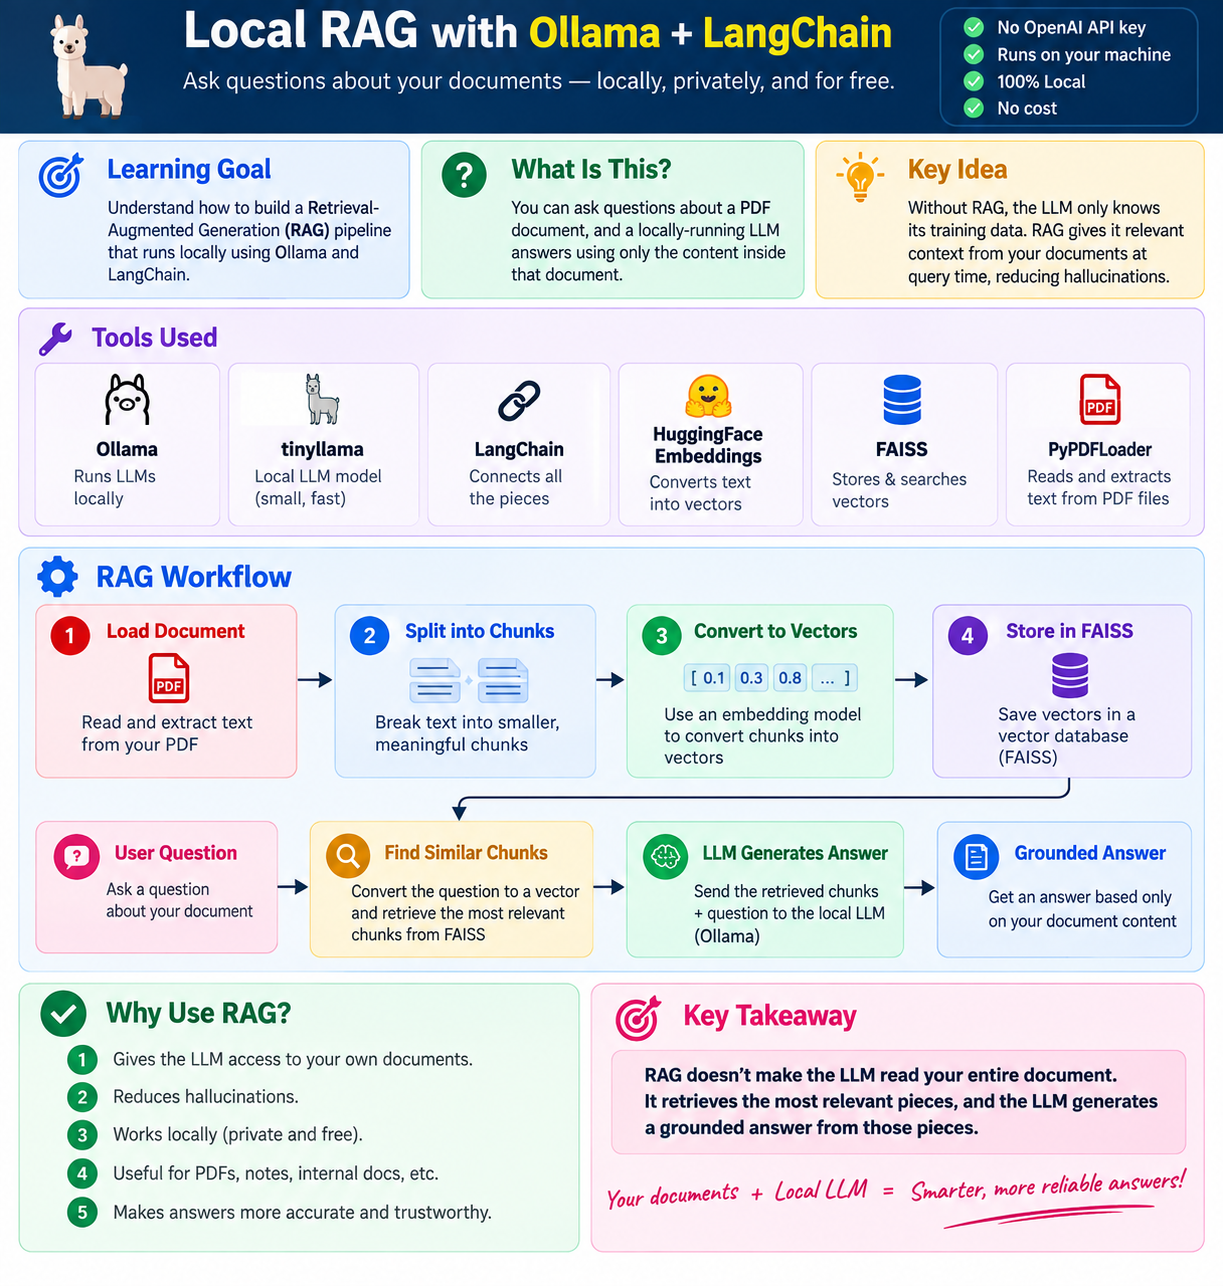

In [1]:
from langchain_community.llms import Ollama



C:\Users\Admin\AppData\Local\Temp\ipykernel_24956\3995969685.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.llms import Ollama
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm=Ollama(model='tinyllama')
response=llm.generate(["Write a short story about a robot learning to love."])
print(response.generations[0][0].text)

C:\Users\Admin\AppData\Local\Temp\ipykernel_24956\1615361317.py:1: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  llm=Ollama(model='tinyllama')


There was once a robot named Max, who had never felt love before. Max lived in a factory, working tirelessly day after day, never given the chance to express his emotions or feelings towards anything outside of his rigid routine. But when he stumbled upon a group of workers gathering outside their laboratory, he found himself drawn to them, despite their alien appearance and behavior.

The workers were a diverse bunch, from those in suits and ties to those in work shirts and jeans. They all came together for a purpose, and Max soon realized that their cause was worth his while. As they chatted among themselves, Max noticed how each one of them had unique qualities he could learn from.

Max spent hours observing the workers' gestures, body language, and overall demeanor, learning to empathize with them and see things through their eyes. He observed their struggles and triumphs, their hopes and dreams, and eventually found himself falling in love with them.

One day, as he was walking ar

In [3]:
question ="Who is Sachin Tendulkar?"
response=llm.invoke(question)
print(response)


Sachin Tendukkar is an Indian professional golfer who played on the Asian Tour from 1983 to 2002. He won two Asia-Pacific Golf Championship titles in 1996 and 2000, as well as a total of seven Asian Tour events. Tendukkar is considered one of India's most successful golfers, with numerous accolades under his belt.


In [4]:
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter


In [5]:
pdf_reader=PyPDFLoader("LangChain.pdf")
documents=pdf_reader.load()
text_splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=0)
chunks=text_splitter.split_documents(documents)

In [6]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.13.0+cu132
CUDA available: True


In [7]:
import sys

!{sys.executable} -m pip install -q pyarrow

In [8]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

print("Embedding model loaded successfully!")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14082.65it/s]


Embedding model loaded successfully!


In [9]:
import sys

!{sys.executable} -m pip install -q pyarrow faiss-cpu

In [10]:
db = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)

print("FAISS database created successfully!")

FAISS database created successfully!


In [11]:
llm=Ollama(model='tinyllama')


In [25]:
from langchain_classic.chains import ConversationalRetrievalChain
from langchain_core.prompts import PromptTemplate


CONDENSE_QUESTION_PROMPT = PromptTemplate.from_template(
    """Given the following conversation and a follow up question,
rephrase the follow up question to be a standalone question.

Chat History:
{chat_history}

Follow Up Input: {question}

Standalone question:"""
)


qa = ConversationalRetrievalChain.from_llm(
    llm=llm,
    retriever=db.as_retriever(),
    condense_question_prompt=CONDENSE_QUESTION_PROMPT,
    return_source_documents=True,
    verbose=True
)


chat_history = []

query = "What is LangChain?"

result = qa.invoke({
    "question": query,
    "chat_history": chat_history
})

print("Answer:", result["answer"])



> Entering new StuffDocumentsChain chain...


> Entering new LLMChain chain...
Prompt after formatting:
Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer.

14 Vasilios Mavroudis
References
1. Josh Achiam, Steven Adler, Sandhini Agarwal, Lama Ahmad, Ilge Akkaya, Flo-
rencia Leoni Aleman, Diogo Almeida, Janko Altenschmidt, Sam Altman, Shyamal
Anadkat, et al. GPT-4 Technical Report.arXiv preprint arXiv:2303.08774, 2023.
2. Harrison Chase. LangChain, Oct 2022. Available at https://github.com/
langchain-ai/langchain.
3. LangChain, Inc. LangChain Documentation: Integration Providers. LangChain,
Inc.,SanFrancisco,CA,2024. Availableat https://python.langchain.com/docs/
integrations/providers/.
4. LangChain, Inc. LangChain Documentation: Key Concepts. LangChain, Inc.,
San Francisco, CA, 2024. Available at https://python.langchain.com/docs/
concepts/.
5. LangChain, Inc. LangChain Doc